Running: ./bin/kmeans_cpu -k 16 -d 16 -i ./tests/random-n2048-d16-c16.txt -m 150 -t 1e-05 -s 8675309
 -> CPU ./tests/random-n2048-d16-c16.txt: 150 iters, 0.020900 ms/iter
Running: ./bin/kmeans_cpu -k 16 -d 24 -i ./tests/random-n16384-d24-c16.txt -m 150 -t 1e-05 -s 8675309
 -> CPU ./tests/random-n16384-d24-c16.txt: 150 iters, 0.249520 ms/iter
Running: ./bin/kmeans_cpu -k 16 -d 32 -i ./tests/random-n65536-d32-c16.txt -m 150 -t 1e-05 -s 8675309
 -> CPU ./tests/random-n65536-d32-c16.txt: 150 iters, 5.121895 ms/iter
Running: ./bin/kmeans_cuda_basic -k 16 -d 16 -i ./tests/random-n2048-d16-c16.txt -m 150 -t 1e-05 -s 8675309
 -> CUDA_basic ./tests/random-n2048-d16-c16.txt: 150 iters, 43.077674 ms/iter
Running: ./bin/kmeans_cuda_basic -k 16 -d 24 -i ./tests/random-n16384-d24-c16.txt -m 150 -t 1e-05 -s 8675309
 -> CUDA_basic ./tests/random-n16384-d24-c16.txt: 150 iters, 30.910913 ms/iter
Running: ./bin/kmeans_cuda_basic -k 16 -d 32 -i ./tests/random-n65536-d32-c16.txt -m 150 -t 1e-05 -s 8675309


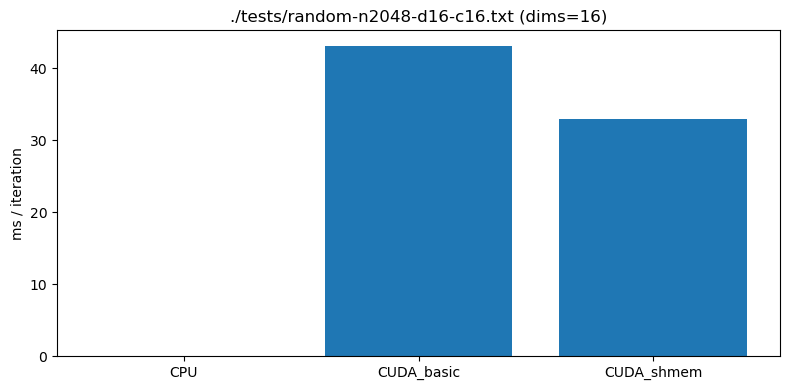

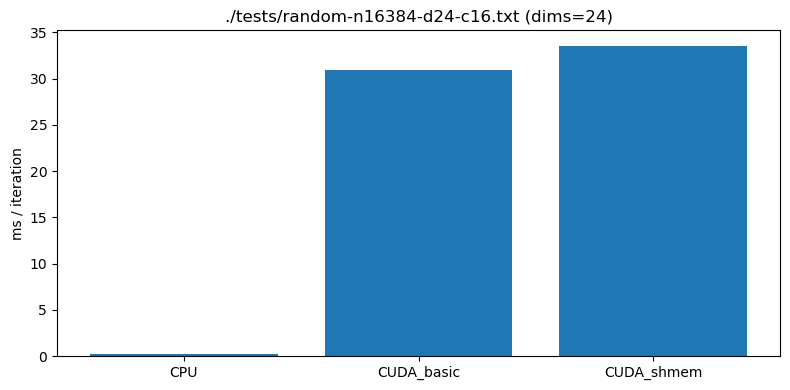

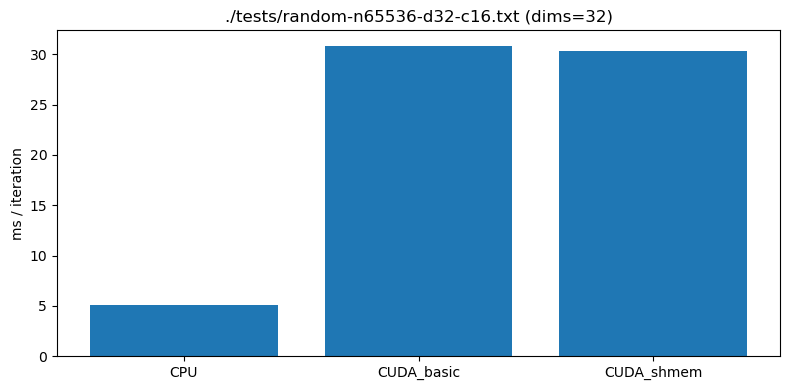

In [5]:
#!/usr/bin/env python3
import re
import subprocess
import matplotlib.pyplot as plt
import os
import stat

# Binaries for each version of k-means
binaries = {
    "CPU": "./bin/kmeans_cpu",
    "CUDA_basic": "./bin/kmeans_cuda_basic",
    "CUDA_shmem": "./bin/kmeans_cuda_shmem",
    #"Thrust": "./bin/kmeans_thrust"
}

# Input files to test (filename, dims)
inputs = [
    ("./tests/random-n2048-d16-c16.txt", 16),
    ("./tests/random-n16384-d24-c16.txt", 24),
    ("./tests/random-n65536-d32-c16.txt", 32)
]

# Common params
k = 16
max_iter = 150
threshold = 1e-5
seed = 8675309

results = {}  # (impl, input) -> (iters, ms_per_iter)

for impl, binpath in binaries.items():
    for fname, dims in inputs:
        # Ensure the binary is executable
        if not os.access(binpath, os.X_OK):
            print(f"[INFO] Setting execute permission for {binpath}")
            os.chmod(binpath, os.stat(binpath).st_mode | stat.S_IEXEC)

        cmd = f"{binpath} -k {k} -d {dims} -i {fname} -m {max_iter} -t {threshold} -s {seed}"
        print("Running:", cmd)
        try:
            out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT).decode()
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] {impl} on {fname} failed:\n{e.output.decode()}")
            continue

        # Output should have a line like: "150,0.123456"
        m = re.search(r"(\d+)\s*,\s*([0-9]*\.?[0-9]+)", out)
        if not m:
            print(f"[WARN] No timing found for {impl} / {fname}")
            print("Output was:\n", out)
            continue

        iters = int(m.group(1))
        ms_per_iter = float(m.group(2))
        results[(impl, fname)] = (iters, ms_per_iter)

        print(f" -> {impl} {fname}: {iters} iters, {ms_per_iter:.6f} ms/iter")

# Plot simple bar charts per input file
for fname, dims in inputs:
    plt.figure(figsize=(8, 4))
    labels, times = [], []
    for impl in binaries.keys():
        key = (impl, fname)
        if key in results:
            labels.append(impl)
            times.append(results[key][1])

    plt.bar(labels, times)
    plt.title(f"{fname} (dims={dims})")
    plt.ylabel("ms / iteration")
    plt.tight_layout()
    plt.show()
